### Projet : Prédiction de la qualité de l'air dans les villes marocaines
# Étape 4 (Bonus) : Federated Learning — Apprentissage Fédéré
On va :
1. Partitionner les données par ville (chaque ville = un client fédéré)
2. Simuler plusieurs **rounds de FedAvg**
3. Observer la convergence du modèle global
4. Comparer avec le modèle centralisé de l'étape 3

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## 1. Chargement des données et partition par ville

In [9]:
# Charger le dataset propre (issu de l'étape 2)
df = pd.read_csv("Data/data_clean.csv")

FEATURES = [col for col in df.columns if col not in ['pm2_5', 'ville']]
TARGET   = 'pm2_5'
VILLES   = df['ville'].unique().tolist()

print(f"Nombre total de lignes : {len(df)}")
print(f"Villes (clients)       : {VILLES}")
print(f"Features               : {len(FEATURES)}")
print()

# Afficher la distribution des données par ville
print("Répartition des données par ville (client fédéré) :")
print("-" * 40)
for ville in VILLES:
    n = len(df[df['ville'] == ville])
    print(f"  {ville:12s} : {n} lignes  ({n/len(df)*100:.0f}%)")

Nombre total de lignes : 212
Villes (clients)       : ['Casablanca', 'Rabat', 'Marrakech', 'Fes']
Features               : 20

Répartition des données par ville (client fédéré) :
----------------------------------------
  Casablanca   : 53 lignes  (25%)
  Rabat        : 53 lignes  (25%)
  Marrakech    : 53 lignes  (25%)
  Fes          : 53 lignes  (25%)


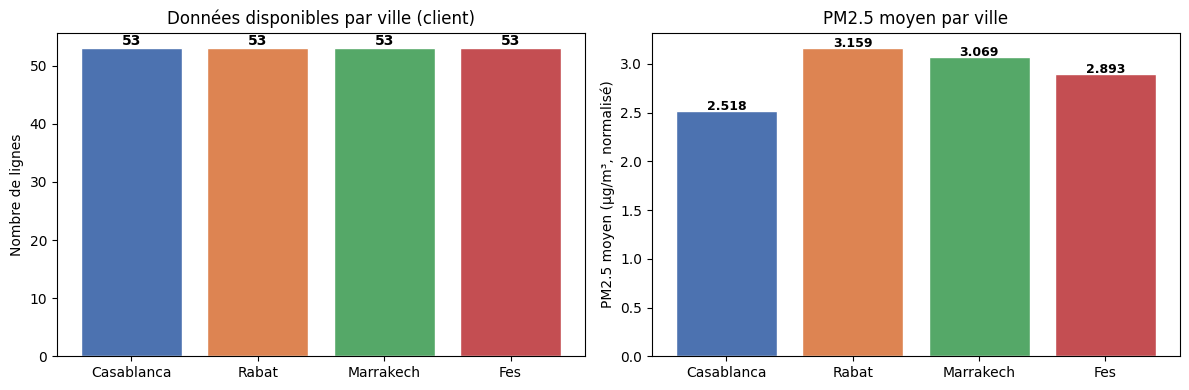

Graphique sauvegardé : repartition_villes.png


In [10]:
# Visualiser la distribution des données par ville
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
couleurs = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Nombre de lignes par ville
counts = [len(df[df['ville']==v]) for v in VILLES]
axes[0].bar(VILLES, counts, color=couleurs, edgecolor='white')
axes[0].set_title('Données disponibles par ville (client)', fontsize=12)
axes[0].set_ylabel('Nombre de lignes')
for i, v in enumerate(counts):
    axes[0].text(i, v+0.5, str(v), ha='center', fontweight='bold')

# PM2.5 moyen par ville
pm25_moy = [df[df['ville']==v]['pm2_5'].mean() for v in VILLES]
axes[1].bar(VILLES, pm25_moy, color=couleurs, edgecolor='white')
axes[1].set_title('PM2.5 moyen par ville', fontsize=12)
axes[1].set_ylabel('PM2.5 moyen (µg/m³, normalisé)')
for i, v in enumerate(pm25_moy):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('repartition_villes.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : repartition_villes.png")

## 2. Préparation : Split global Train / Test

In [11]:
X_all = df[FEATURES]
y_all = df[TARGET]

# Split global 80% / 20% — MÊME split que l'étape 3 (random_state=42)
X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

print("Split global :")
print(f"  Train : {len(X_train_global)} lignes")
print(f"  Test  : {len(X_test_global)} lignes")
print()

# Partition par ville : chaque client garde les données de train qui lui appartiennent
clients = {}
for ville in VILLES:
    idx_ville = df[df['ville'] == ville].index
    idx_train_ville = [i for i in idx_ville if i in X_train_global.index]
    clients[ville] = {
        'X_train': X_train_global.loc[idx_train_ville],
        'y_train': y_train_global.loc[idx_train_ville]
    }
    print(f"  Client {ville:12s} : {len(idx_train_ville)} lignes de train")

print()
print("Chaque ville a ses données locales — le serveur ne les voit JAMAIS !")

Split global :
  Train : 169 lignes
  Test  : 43 lignes

  Client Casablanca   : 43 lignes de train
  Client Rabat        : 40 lignes de train
  Client Marrakech    : 45 lignes de train
  Client Fes          : 41 lignes de train

Chaque ville a ses données locales — le serveur ne les voit JAMAIS !


## 3. Modèle de référence — Régression Linéaire Centralisée

In [12]:
# Modèle centralisé (Linear Regression — même que étape 3)
modele_centralise = LinearRegression()
modele_centralise.fit(X_train_global, y_train_global)
y_pred_centralise = modele_centralise.predict(X_test_global)

mae_c  = mean_absolute_error(y_test_global, y_pred_centralise)
rmse_c = np.sqrt(mean_squared_error(y_test_global, y_pred_centralise))
r2_c   = r2_score(y_test_global, y_pred_centralise)

print("MODÈLE CENTRALISÉ (référence) :")
print("=" * 45)
print(f"  MAE  = {mae_c:.4f} µg/m³")
print(f"  RMSE = {rmse_c:.4f} µg/m³")
print(f"  R²   = {r2_c:.4f}")
print()
print("C'est la performance maximale qu'on espère approcher avec le FL.")

MODÈLE CENTRALISÉ (référence) :
  MAE  = 0.4935 µg/m³
  RMSE = 0.6188 µg/m³
  R²   = 0.8140

C'est la performance maximale qu'on espère approcher avec le FL.


## 4. Simulation du Federated Learning — FedAvg

In [13]:
# Initialisation du modèle global
NUM_ROUNDS = 10       
n_features = len(FEATURES)

# Paramètres initiaux à zéro (le modèle ne sait rien au départ)
global_coef      = np.zeros(n_features)
global_intercept = 0.0

# Historique des performances par round
historique = []

print("=" * 55)
print("   SIMULATION FEDERATED LEARNING — FedAvg")
print("=" * 55)
print(f"  Nombre de clients : {len(VILLES)} villes")
print(f"  Nombre de rounds  : {NUM_ROUNDS}")
print(f"  Algorithme        : FedAvg (moyenne pondérée)")
print("=" * 55)
print()

for rnd in range(1, NUM_ROUNDS + 1):
    
    # ─── ÉTAPE 1 : Chaque ville entraîne un modèle local ───
    local_coefs      = []
    local_intercepts = []
    local_sizes      = []
    
    for ville in VILLES:
        X_loc = clients[ville]['X_train'].values
        y_loc = clients[ville]['y_train'].values
    
        modele_local = SGDRegressor(
            max_iter=200,
            learning_rate='constant',
            eta0=0.005,
            random_state=42
        )
        
        # Round 1 : entraînement normal
        # Rounds suivants : warm-start depuis les paramètres globaux
        if rnd == 1:
            modele_local.fit(X_loc, y_loc)
        else:
            modele_local.fit(X_loc, y_loc)
            modele_local.coef_      = global_coef.copy()
            modele_local.intercept_ = np.array([global_intercept])
            modele_local.partial_fit(X_loc, y_loc)
        
        # Sauvegarder les paramètres locaux
        local_coefs.append(modele_local.coef_.copy())
        local_intercepts.append(float(modele_local.intercept_[0]))
        local_sizes.append(len(X_loc))
    
    # ─── ÉTAPE 2 : FedAvg — Moyenne pondérée des paramètres ───
    n_total = sum(local_sizes)
    global_coef      = sum(c * (s / n_total) for c, s in zip(local_coefs, local_sizes))
    global_intercept = sum(b * (s / n_total) for b, s in zip(local_intercepts, local_sizes))
    
    # ─── ÉTAPE 3 : Évaluer le modèle global sur le set de test ───
    y_pred_fed = X_test_global.values @ global_coef + global_intercept
    
    mae_fed  = mean_absolute_error(y_test_global, y_pred_fed)
    rmse_fed = np.sqrt(mean_squared_error(y_test_global, y_pred_fed))
    r2_fed   = r2_score(y_test_global, y_pred_fed)
    
    historique.append({
        'round': rnd,
        'mae':   mae_fed,
        'rmse':  rmse_fed,
        'r2':    r2_fed
    })
    
    print(f"  Round {rnd:2d}/{NUM_ROUNDS} → R²={r2_fed:+.4f}  MAE={mae_fed:.4f}  RMSE={rmse_fed:.4f}")

print()
print("Entraînement fédéré terminé !")

   SIMULATION FEDERATED LEARNING — FedAvg
  Nombre de clients : 4 villes
  Nombre de rounds  : 10
  Algorithme        : FedAvg (moyenne pondérée)

  Round  1/10 → R²=-1.5237  MAE=2.0758  RMSE=2.2796
  Round  2/10 → R²=-0.9810  MAE=1.8240  RMSE=2.0197
  Round  3/10 → R²=-0.5807  MAE=1.6064  RMSE=1.8041
  Round  4/10 → R²=-0.2752  MAE=1.4168  RMSE=1.6204
  Round  5/10 → R²=-0.0394  MAE=1.2513  RMSE=1.4629
  Round  6/10 → R²=+0.1435  MAE=1.1088  RMSE=1.3280
  Round  7/10 → R²=+0.2856  MAE=0.9929  RMSE=1.2128
  Round  8/10 → R²=+0.3963  MAE=0.8988  RMSE=1.1150
  Round  9/10 → R²=+0.4825  MAE=0.8209  RMSE=1.0322
  Round 10/10 → R²=+0.5499  MAE=0.7545  RMSE=0.9627

Entraînement fédéré terminé !


## 5. Visualisation de la convergence

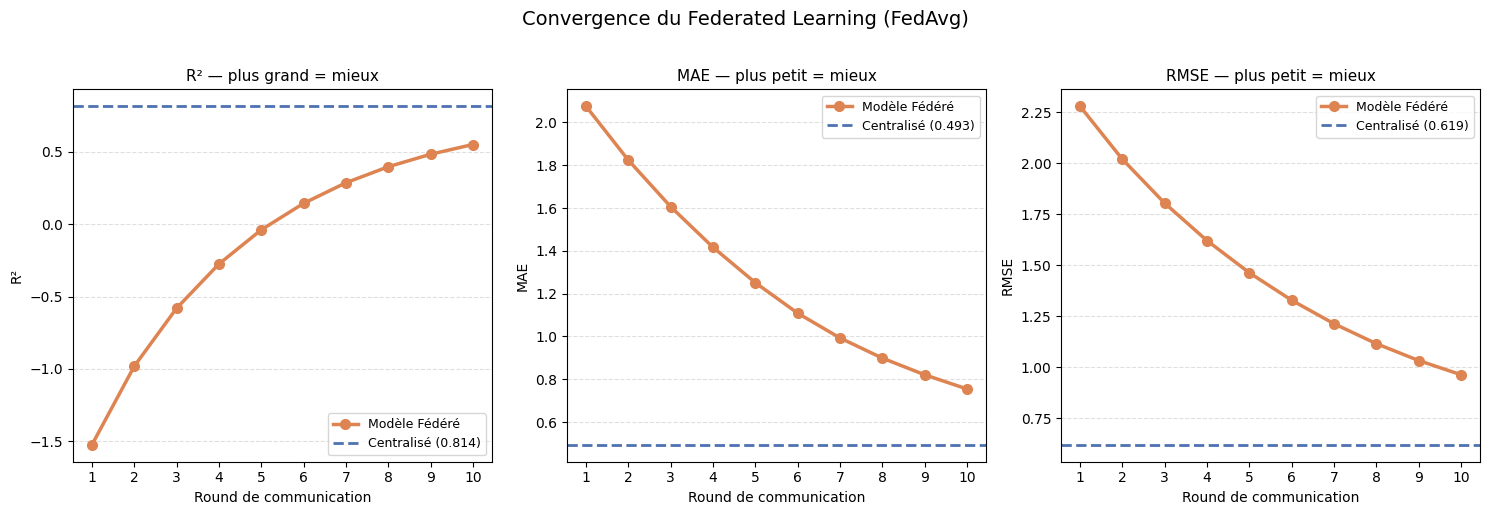

Graphique sauvegardé : convergence_federated.png


In [14]:
df_hist = pd.DataFrame(historique)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metriques = [
    ('r2',   'R²',   'plus grand = mieux', True),
    ('mae',  'MAE',  'plus petit = mieux', False),
    ('rmse', 'RMSE', 'plus petit = mieux', False),
]
refs = [r2_c, mae_c, rmse_c]
couleur_fed = '#DD8452'
couleur_ref = '#4C72B0'

for ax, (col, label, hint, higher_better), ref_val in zip(axes, metriques, refs):
    # Courbe de convergence fédérée
    ax.plot(df_hist['round'], df_hist[col], 
            color=couleur_fed, marker='o', linewidth=2.5, 
            markersize=7, label='Modèle Fédéré')
    
    # Ligne de référence centralisée
    ax.axhline(ref_val, color=couleur_ref, linestyle='--', 
               linewidth=2, label=f'Centralisé ({ref_val:.3f})')
    
    ax.set_title(f'{label} — {hint}', fontsize=11)
    ax.set_xlabel('Round de communication')
    ax.set_ylabel(label)
    ax.set_xticks(df_hist['round'])
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Convergence du Federated Learning (FedAvg)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('convergence_federated.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : convergence_federated.png")

## 6. Performance locale par ville (avant FedAvg)

In [15]:
print("Performance des modèles locaux (entraîné et évalué par ville) :")
print("=" * 55)

r2_locaux = {}
for ville in VILLES:
    X_loc = clients[ville]['X_train'].values
    y_loc = clients[ville]['y_train'].values
    
    # Entraîner un modèle local
    m_local = LinearRegression().fit(X_loc, y_loc)
    
    # Évaluer sur le test GLOBAL (pour comparaison équitable)
    y_pred_loc = m_local.predict(X_test_global.values)
    r2_loc  = r2_score(y_test_global, y_pred_loc)
    mae_loc = mean_absolute_error(y_test_global, y_pred_loc)
    r2_locaux[ville] = r2_loc
    
    print(f"  {ville:12s} → R²={r2_loc:+.4f}  MAE={mae_loc:.4f}")

print()
print(f"  Modèle fédéré final → R²={df_hist['r2'].iloc[-1]:+.4f}  MAE={df_hist['mae'].iloc[-1]:.4f}")
print(f"  Modèle centralisé   → R²={r2_c:+.4f}  MAE={mae_c:.4f}")

Performance des modèles locaux (entraîné et évalué par ville) :
  Casablanca   → R²=+0.4180  MAE=0.8371
  Rabat        → R²=-0.4520  MAE=1.3312
  Marrakech    → R²=+0.1170  MAE=1.0750
  Fes          → R²=-1.5558  MAE=1.8839

  Modèle fédéré final → R²=+0.5499  MAE=0.7545
  Modèle centralisé   → R²=+0.8140  MAE=0.4935


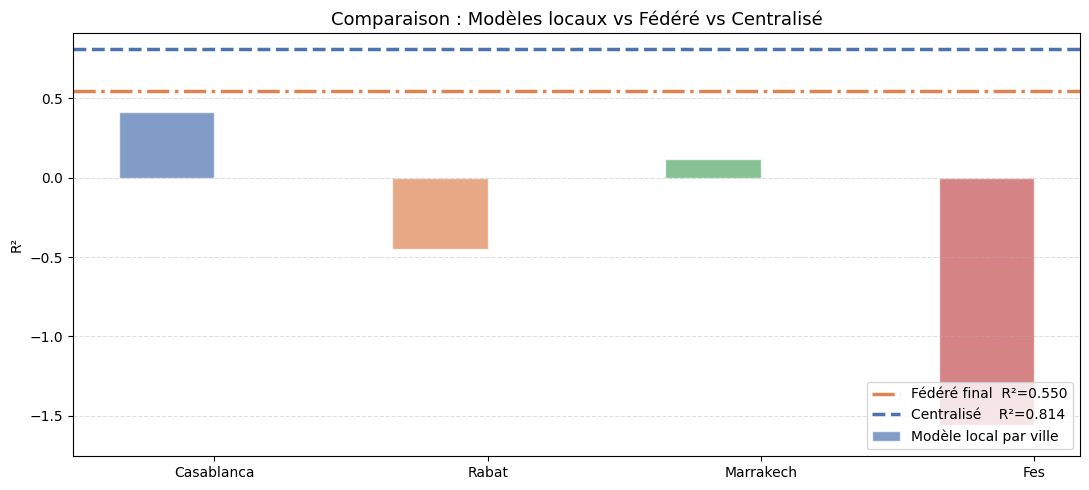

Graphique sauvegardé : comparaison_local_federe_centralise.png


In [16]:
# Graphique comparatif : Local vs Fédéré vs Centralisé
fig, ax = plt.subplots(figsize=(11, 5))

couleurs_villes = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
r2_vals_locaux = [r2_locaux[v] for v in VILLES]

x = np.arange(len(VILLES))
width = 0.35

bars_loc = ax.bar(x - width/2, r2_vals_locaux, width, 
                  color=couleurs_villes, alpha=0.7, edgecolor='white', label='Modèle local par ville')

ax.axhline(df_hist['r2'].iloc[-1], color='#DD8452', linestyle='-.',
           linewidth=2.5, label=f'Fédéré final  R²={df_hist["r2"].iloc[-1]:.3f}')
ax.axhline(r2_c, color='#4C72B0', linestyle='--',
           linewidth=2.5, label=f'Centralisé    R²={r2_c:.3f}')

ax.set_xticks(x)
ax.set_xticklabels(VILLES)
ax.set_ylabel('R²')
ax.set_title('Comparaison : Modèles locaux vs Fédéré vs Centralisé', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(min(min(r2_vals_locaux), df_hist['r2'].iloc[-1]) - 0.2, r2_c + 0.1)

plt.tight_layout()
plt.savefig('comparaison_local_federe_centralise.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : comparaison_local_federe_centralise.png")

## 7. Tableau de comparaison final

In [17]:
# Récupérer les métriques finales du modèle fédéré
fed_final = df_hist.iloc[-1]
y_pred_fed_final = X_test_global.values @ global_coef + global_intercept

# Construire le tableau
tableau = pd.DataFrame({
    'Modèle':  ['Centralisé (LR)', 'Fédéré (FedAvg)', 'Différence'],
    'MAE':     [round(mae_c, 4),  round(fed_final['mae'], 4),
                round(fed_final['mae'] - mae_c, 4)],
    'RMSE':    [round(rmse_c, 4), round(fed_final['rmse'], 4),
                round(fed_final['rmse'] - rmse_c, 4)],
    'R²':      [round(r2_c, 4),   round(fed_final['r2'], 4),
                round(fed_final['r2'] - r2_c, 4)],
})

print("TABLEAU COMPARATIF FINAL")
print("=" * 55)
print(tableau.to_string(index=False))
print()
gap_r2 = abs(r2_c - fed_final['r2'])
print(f"  Écart de R² entre centralisé et fédéré : {gap_r2:.4f}")
print()
print("  Interprétation :")
if fed_final['r2'] >= r2_c * 0.9:
    print("  ✓ Le modèle fédéré atteint une performance proche du centralisé")
    print("  ✓ La confidentialité des données est préservée — personne ne partage ses données brutes !")
else:
    print(f"  → Le modèle fédéré est légèrement moins précis ({gap_r2:.3f} de R²)")
    print("  → Ce compromis est acceptable pour protéger la vie privée")
    print("  → Plus de rounds ou plus de données locales amélioreraient le résultat")

TABLEAU COMPARATIF FINAL
         Modèle    MAE   RMSE      R²
Centralisé (LR) 0.4935 0.6188  0.8140
Fédéré (FedAvg) 0.7545 0.9627  0.5499
     Différence 0.2610 0.3438 -0.2641

  Écart de R² entre centralisé et fédéré : 0.2641

  Interprétation :
  → Le modèle fédéré est légèrement moins précis (0.264 de R²)
  → Ce compromis est acceptable pour protéger la vie privée
  → Plus de rounds ou plus de données locales amélioreraient le résultat


## 8. Résumé et conclusion

In [18]:
print("=" * 60)
print("   RÉSUMÉ — FEDERATED LEARNING (BONUS)")
print("=" * 60)
print()
print("  Architecture :")
print(f"    - {len(VILLES)} clients fédérés (une ville = un client)")
print(f"    - {NUM_ROUNDS} rounds de communication")
print(f"    - Algorithme : FedAvg (moyenne pondérée)")
print(f"    - Modèle local : SGDRegressor (gradient stochastique)")
print()
print("  Résultats :")
print(f"    Modèle centralisé → R²={r2_c:.4f}  MAE={mae_c:.4f}")
print(f"    Modèle fédéré     → R²={fed_final['r2']:.4f}  MAE={fed_final['mae']:.4f}")
print()


   RÉSUMÉ — FEDERATED LEARNING (BONUS)

  Architecture :
    - 4 clients fédérés (une ville = un client)
    - 10 rounds de communication
    - Algorithme : FedAvg (moyenne pondérée)
    - Modèle local : SGDRegressor (gradient stochastique)

  Résultats :
    Modèle centralisé → R²=0.8140  MAE=0.4935
    Modèle fédéré     → R²=0.5499  MAE=0.7545

